In [36]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches # 引入 patches 用于绘制矩形块染色

In [37]:
def visualize_maze_with_path(maze, path=None, explored_cells=None):
    plt.figure(figsize=(len(maze[0]), len(maze)))
    plt.imshow(maze, cmap="Greys", interpolation="nearest")

    # 待补充代码：对搜索过的格子染色
    if explored_cells:
        for x, y in explored_cells:
            if maze[x][y]==1:
                continue
            rect = patches.Rectangle(
                (y - 0.5, x - 0.5), 1, 1, linewidth=0, facecolor="lightblue", alpha=0.8
            )
            plt.gca().add_patch(rect)

    # 绘制路径
    if path:
        path_x, path_y = zip(*path)
        plt.plot(path_y, path_x, marker="o", markersize=8, color="red", linewidth=3)

    # 设置坐标轴刻度和边框
    plt.xticks(range(len(maze[0])))
    plt.yticks(range(len(maze)))
    plt.gca().set_xticks([x - 0.5 for x in range(1, len(maze[0]))], minor=True)
    plt.gca().set_yticks([y - 0.5 for y in range(1, len(maze))], minor=True)
    plt.grid(which="minor", color="black", linestyle="-", linewidth=2)

    plt.axis("on")
    plt.show()

In [ ]:
# 提供迷宫的二维数组
maze = [
    [0, 1, 0, 0, 0],
    [0, 1, 0, 1, 0],
    [0, 0, 0, 0, 0],
    [0, 1, 1, 1, 0],
    [0, 0, 0, 1, 0],
]


# 假设给定路径的坐标列表
right_path = [(0, 0), (1, 0), (2, 0), (2, 1), (2, 2), (2, 3), (2, 4), (3, 4), (4, 4)]
directions = [(-1, 0), (1, 0), (0, -1), (0, 1)]
start_pos = (0, 0)
goal_pos = (4, 4)

In [39]:
def valid(x,y):
    return 0 <= x < len(maze) and 0 <= y < len(maze[0]) and maze[x][y] == 0

In [40]:
def dfs(maze, start, goal):
    """
    使用深度优先搜索 (DFS) 寻找迷宫路径。
    
    参数:
        maze: 2D 列表，0 表示可通行，1 表示障碍物
        start: 起点坐标 (row, col)
        goal: 终点坐标 (row, col)
        
    返回:
        path: 从起点到终点的坐标列表，如果没找到则返回 None
        explored_cells: 搜索过程中访问过的所有坐标列表（用于染色可视化）
    """
    rows = len(maze)
    cols = len(maze[0])
    
    # 使用栈 (Stack) 来实现 DFS，栈内存储元组：(当前坐标, 走到当前坐标的路径)
    stack = [(start, [start])]
    
    # 记录已经访问过的节点，避免死循环
    visited = set()
    # 记录探索顺序，用于可视化染色
    explored_cells = []
    
    # 定义四个移动方向：上、下、左、右
    
    while stack:
        current, path = stack.pop()
        
        # 如果已经访问过，则跳过
        if current in visited:
            continue
            
        visited.add(current)
        explored_cells.append(current)
        
        # 如果到达终点，直接返回路径和探索过的格子
        if current == goal:
            return path, explored_cells
            
        # 遍历相邻的节点
        r, c = current
        for dr, dc in directions:
            nr, nc = r + dr, c + dc
            
            # 检查边界和是否为障碍物 (0 为可通行)
            if valid(nr, nc):
                if (nr, nc) not in visited:
                    # 将新节点及其路径压入栈中
                    stack.append(((nr, nc), path + [(nr, nc)]))
                    
    # 如果遍历完都没找到终点
    return None, explored_cells

找到路径，长度为: 9


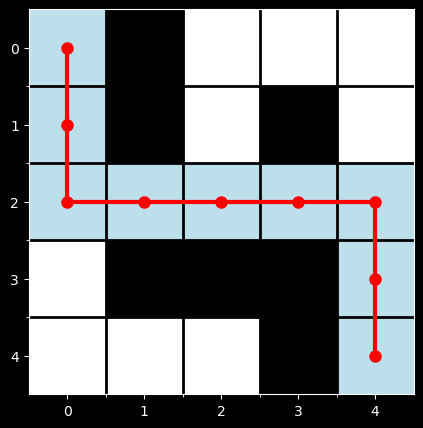

In [41]:
path, explored = dfs(maze, start_pos, goal_pos)

if path:
    print(f"找到路径，长度为: {len(path)}")
else:
    print("未找到有效路径！")

# 调用上一轮补全好的可视化函数 (传入 explored 作为第三个参数)
visualize_maze_with_path(maze, path, explored)

In [42]:
from collections import deque

def bfs(maze, start, goal):
    """
    使用广度优先搜索 (BFS) 寻找迷宫路径。
    
    参数:
        maze: 2D 列表，0 表示可通行，1 表示障碍物
        start: 起点坐标 (row, col)
        goal: 终点坐标 (row, col)
        
    返回:
        path: 从起点到终点的坐标列表，如果没找到则返回 None
        explored_cells: 搜索过程中访问过的所有坐标列表（用于染色可视化）
    """
    rows = len(maze)
    cols = len(maze[0])
    
    # 使用双端队列 (Deque) 来实现 BFS，队列内存储元组：(当前坐标, 走到当前坐标的路径)
    queue = deque([(start, [start])])
    
    # 记录已经访问过的节点，起点在入队时就标记为已访问
    visited = {start}
    # 记录探索顺序，用于可视化染色
    explored_cells = []
    
    # 定义四个移动方向：上、下、左、右
    directions = [(-1, 0), (1, 0), (0, -1), (0, 1)]
    
    while queue:
        # BFS 的核心：从队首取出节点 (FIFO)
        current, path = queue.popleft() 
        
        explored_cells.append(current)
        
        # 如果到达终点，直接返回路径和探索过的格子
        if current == goal:
            return path, explored_cells
            
        # 遍历相邻的节点
        r, c = current
        for dr, dc in directions:
            nr, nc = r + dr, c + dc
            
            # 检查边界和是否为障碍物 (0 为可通行)
            if valid(nr, nc):
                if (nr, nc) not in visited:
                    # 发现新节点时立即标记为已访问，防止重复入队
                    visited.add((nr, nc)) 
                    # 将新节点及其路径加入队尾
                    queue.append(((nr, nc), path + [(nr, nc)]))
                    
    # 如果遍历完都没找到终点
    return None, explored_cells

找到路径，长度为: 9


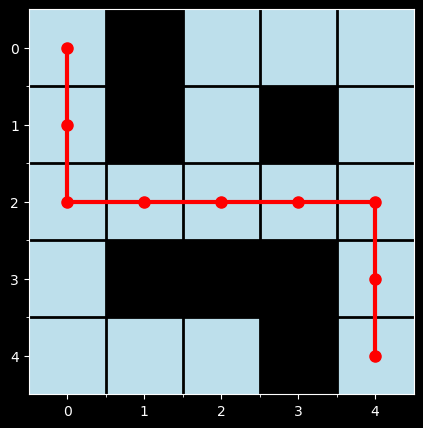

In [43]:
path, explored = bfs(maze, start_pos, goal_pos)

if path:
    print(f"找到路径，长度为: {len(path)}")
else:
    print("未找到有效路径！")

# 调用上一轮补全好的可视化函数 (传入 explored 作为第三个参数)
visualize_maze_with_path(maze, path, explored)

In [44]:
import heapq

def dijkstra(maze, start, goal):
    """
    使用 Dijkstra 算法寻找迷宫路径。
    
    参数:
        maze: 2D 列表，0 表示可通行，1 表示障碍物
        start: 起点坐标 (row, col)
        goal: 终点坐标 (row, col)
        
    返回:
        path: 从起点到终点的坐标列表，如果没找到则返回 None
        explored_cells: 搜索过程中访问过的所有坐标列表（用于染色可视化）
    """
    rows = len(maze)
    cols = len(maze[0])
    
    # 优先队列，存储格式为: (当前代价, 当前坐标, 走到当前坐标的路径)
    # heapq 默认根据元组的第一个元素（即代价 cost）进行最小堆排序
    pq = [(0, start, [start])]
    
    # 字典记录从起点到达每个节点的最短距离（已知最小代价）
    costs = {start: 0}
    
    # 记录探索顺序，用于可视化染色
    explored_cells = []
    
    # 定义四个移动方向：上、下、左、右
    directions = [(-1, 0), (1, 0), (0, -1), (0, 1)]
    
    while pq:
        # 每次弹出当前代价最小的节点
        current_cost, current, path = heapq.heappop(pq)
        
        # 如果当前出队的代价已经大于字典里记录的最小代价，说明它是冗余的旧数据，直接跳过
        if current_cost > costs.get(current, float('inf')):
            continue
            
        explored_cells.append(current)
        
        # 如果到达终点，返回路径和探索过的格子
        if current == goal:
            return path, explored_cells
            
        # 遍历相邻的节点
        r, c = current
        for dr, dc in directions:
            nr, nc = r + dr, c + dc
            
            # 检查边界和是否为障碍物 (0 为可通行)
            if valid(nr, nc):
                new_cost = current_cost + 1  # 迷宫中每走一步代价视为 1
                
                # 如果找到了更低代价到达该相邻节点的路径（或者该节点是第一次被发现）
                if new_cost < costs.get((nr, nc), float('inf')):
                    costs[(nr, nc)] = new_cost
                    # 将更新后的代价、新节点以及路径推入优先队列
                    heapq.heappush(pq, (new_cost, (nr, nc), path + [(nr, nc)]))
                    
    # 如果遍历完都没找到终点
    return None, explored_cells

Dijkstra 找到路径，长度为: 9


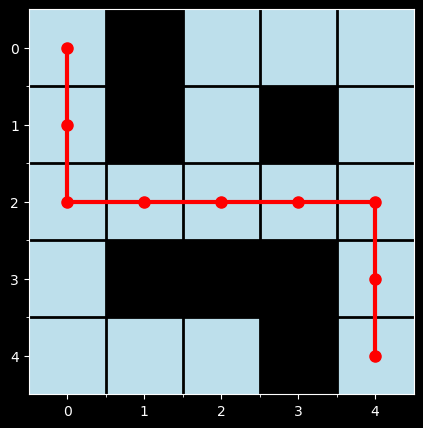

In [45]:
# 运行 Dijkstra 算法
path_dij, explored_dij = dijkstra(maze, start_pos, goal_pos)

if path_dij:
    print(f"Dijkstra 找到路径，长度为: {len(path_dij)}")
else:
    print("未找到有效路径！")

# 可视化 Dijkstra 的搜索过程
visualize_maze_with_path(maze, path_dij, explored_dij)

In [46]:
import heapq

def manhattan_distance(p1, p2):
    """
    计算两个坐标点之间的曼哈顿距离，作为 A* 算法的启发函数 (Heuristic)。
    """
    return abs(p1[0] - p2[0]) + abs(p1[1] - p2[1])

def a_star(maze, start, goal):
    """
    使用 A* 算法寻找迷宫路径。
    
    参数:
        maze: 2D 列表，0 表示可通行，1 表示障碍物
        start: 起点坐标 (row, col)
        goal: 终点坐标 (row, col)
        
    返回:
        path: 从起点到终点的坐标列表，如果没找到则返回 None
        explored_cells: 搜索过程中访问过的所有坐标列表（用于染色可视化）
    """
    rows = len(maze)
    cols = len(maze[0])
    
    # g_score 记录从起点到每个节点的最短实际距离 (代价)
    g_score = {start: 0}
    
    # 优先队列，存储格式为: (f_score, 当前坐标, 走到当前坐标的路径)
    # f_score = g_score + heuristic (曼哈顿距离)
    f_start = manhattan_distance(start, goal)
    pq = [(f_start, start, [start])]
    
    # 记录探索顺序，用于可视化染色
    explored_cells = []
    
    # 定义四个移动方向：上、下、左、右
    directions = [(-1, 0), (1, 0), (0, -1), (0, 1)]
    
    while pq:
        # 每次弹出 f_score 最小的节点
        current_f, current, path = heapq.heappop(pq)
        
        # 为了避免重复探索，我们在出队时将其记录为已探索
        # 注意：这里我们用一个简单的方式，实际应用中可以配合一个 closed_set
        if current in explored_cells:
            continue
            
        explored_cells.append(current)
        
        # 如果到达终点，返回路径和探索过的格子
        if current == goal:
            return path, explored_cells
            
        # 遍历相邻的节点
        r, c = current
        for dr, dc in directions:
            nr, nc = r + dr, c + dc
            
            # 检查边界和是否为障碍物 (0 为可通行)
            if valid(nr, nc):
                # 迷宫中每走一步实际代价视为 1
                tentative_g_score = g_score.get(current, float('inf')) + 1
                
                # 如果找到了一条到达相邻节点的更优路径（或者该节点是第一次被发现）
                if tentative_g_score < g_score.get((nr, nc), float('inf')):
                    g_score[(nr, nc)] = tentative_g_score
                    # 计算新的 f_score
                    f_score = tentative_g_score + manhattan_distance((nr, nc), goal)
                    # 将更新后的代价、新节点以及路径推入优先队列
                    heapq.heappush(pq, (f_score, (nr, nc), path + [(nr, nc)]))
                    
    # 如果遍历完都没找到终点
    return None, explored_cells

A* 找到路径，长度为: 9


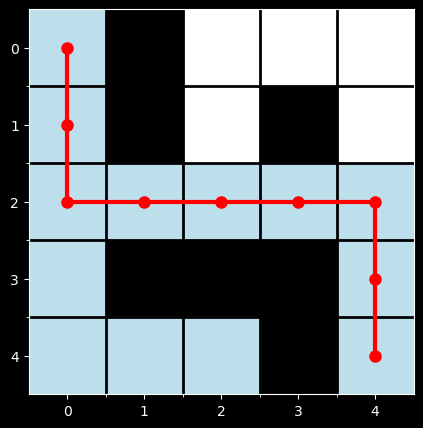

In [47]:
# 运行 A* 算法
path_astar, explored_astar = a_star(maze, start_pos, goal_pos)

if path_astar:
    print(f"A* 找到路径，长度为: {len(path_astar)}")
else:
    print("未找到有效路径！")

# 可视化 A* 的搜索过程
visualize_maze_with_path(maze, path_astar, explored_astar)